## Overview

**Problem Statement:**

The travel and hospitality industry often faces significant revenue losses due to last-minute booking cancellations, which disrupt occupancy planning and resource allocation. Understanding customer behavior and identifying high-risk bookings is essential for optimizing operations and improving profitability, and reduce revenue loss.

**Objective:**

To develop a predictive model that identifies high-risk bookings before the scheduled arrival date, based on customer demographics and historical booking behaviour to reduce last-minute cancellations and optimize occupancy rates.


**Goal:**

To identify bookings with a high likelihood of cancellation with over 80% accuracy, allowing the company to intervene effectively, thus reducing cancellation rates and increasing overall revenue.

## Import Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import datetime
import numpy as np
import pandas as pd
import seaborn as sns
# import pandasql as ps
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
import sklearn.metrics as metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import tree
from xgboost import XGBClassifier

## Load Data

In [ ]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('train.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,0.0,0,BB,ITA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5


In [ ]:
print (f'Data Shape: {df.shape}')

Data Shape: (83293, 33)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

## Data Cleaning

### Check Duplicated and Missing Data

In [ ]:
#drop unique identifier
df = df.drop(columns='hotel', axis =1)

In [ ]:
print (f'Duplicated Data: {df.duplicated().sum()}')

Duplicated Data: 0


In [ ]:
missing = df.isnull().sum().reset_index()
missing.columns = ['features', 'missing_values']
missing['percentage'] = (missing['missing_values']/len(df)) *100
missing

,features,missing_values,percentage
0,is_canceled,0,0.000000
1,lead_time,0,0.000000
2,arrival_date_year,0,0.000000
3,arrival_date_month,0,0.000000
4,arrival_date_week_number,0,0.000000
5,arrival_date_day_of_month,0,0.000000
6,stays_in_weekend_nights,0,0.000000
7,stays_in_week_nights,0,0.000000
8,adults,0,0.000000
9,children,3,0.003602


- Drop company column since it has >50% missing and therefore low relevance
- Fill in `children` with 0.0 for no children
- Fill in `country` with the mode (most common value)
- Fill in `agent` with 0.0 for direct bookings

In [ ]:
df = df.drop(columns=['company'])
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)

In [ ]:
#check
df.isnull().sum()

,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0
children,0


### Data Manipulation

In [ ]:
#combine number of guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

#combine number of stays in week nights and stays in weekend nights
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

#calculate profit
df['profit'] = df['adr']*df['total_nights']

#check if customer got assigned same room type as reserved or not
df['same_room'] = (df['reserved_room_type'] == df['assigned_room_type']).astype(int)

#arrival date
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    errors = 'coerce'
)

When performing the arrival date combination, an error occured. After double checking the date, turns out that 2018 is NOT a leap year. So we need to recheck the missing value.

In [ ]:
df[df['arrival_date'].isnull()]

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,total_guests,total_nights,profit,same_room,arrival_date
1565,1,117,2018,February,10,29,1,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,1566,2.0,3,225.00,1,NaT
3069,0,117,2018,February,10,29,1,2,2,0.0,0,BB,IRN,Offline TA/TO,TA/TO,0,0,0,A,A,2,No Deposit,134.0,0,Transient-Party,86.33,0,0,Check-Out,2018-03-03,3070,2.0,3,258.99,1,NaT
3081,1,138,2018,February,10,29,3,7,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,40.50,0,1,Canceled,2017-12-31,3082,2.0,10,405.00,1,NaT
3792,1,117,2018,February,10,29,1,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,3793,2.0,3,225.00,1,NaT
4488,1,21,2018,February,10,29,1,3,1,0.0,0,BB,TUR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0,Transient,102.05,0,0,Canceled,2018-02-26,4489,1.0,4,408.20,1,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77857,1,117,2018,February,10,29,1,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,77858,2.0,3,225.00,1,NaT
78926,1,50,2018,February,10,29,1,0,2,0.0,0,SC,CN,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,0,Transient,76.50,0,0,Canceled,2018-02-25,78927,2.0,1,76.50,1,NaT
79306,1,40,2018,February,10,29,1,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,48.00,0,2,Canceled,2018-01-23,79307,2.0,5,240.00,1,NaT
81571,1,117,2018,February,10,29,1,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19.0,44,Transient,75.00,0,0,Canceled,2017-12-18,81572,2.0,3,225.00,1,NaT


In [ ]:
len(df[df['arrival_date'].isnull()])/len(df)*100

0.07803777028081592

Since it is <1% and is an invalid date, we can drop the data.

In [ ]:
df = df.dropna()

Ensure the number of guests is reasonable:
- No `total_guests` should be = 0
- No 2 `adults` with 10 `children` or 10 `babies` should be in 1 room

In [ ]:
df = df[df['total_guests']!=0]
df = df[(df['children']<5) & (df['babies']<5)]

In [ ]:
print(f'Data Shape: {df.shape}')

Data Shape: (83098, 36)


## Exploratory Data Analysis

### Overall Trend

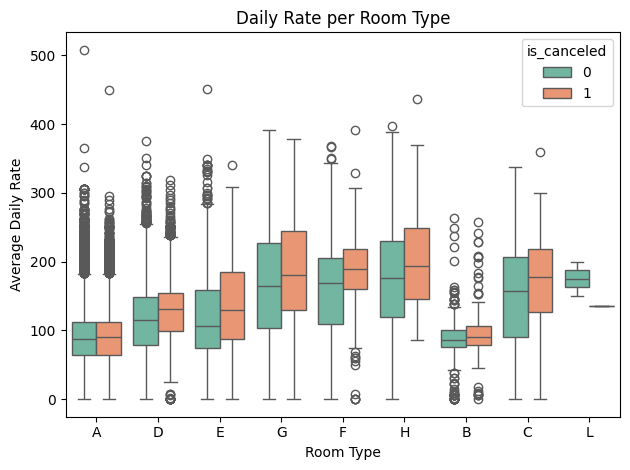

In [ ]:
data = df[df['is_canceled'] == 0]
room_order = ['A','B','C','D','E','F','G','H','L']
sns.boxplot(data = df, x = 'reserved_room_type', y = 'adr', hue ='is_canceled', palette = 'Set2')
plt.title('Daily Rate per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Daily Rate')

plt.tight_layout()
plt.show()

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)
monthly_adr = df.groupby(['arrival_date_month'])['adr'].mean().sort_index()
monthly_adr

,adr
arrival_date_month,
January,70.721622
February,73.667444
March,80.646208
April,99.992556
May,108.350342
June,116.840495
July,127.590963
August,140.195220
September,104.935960


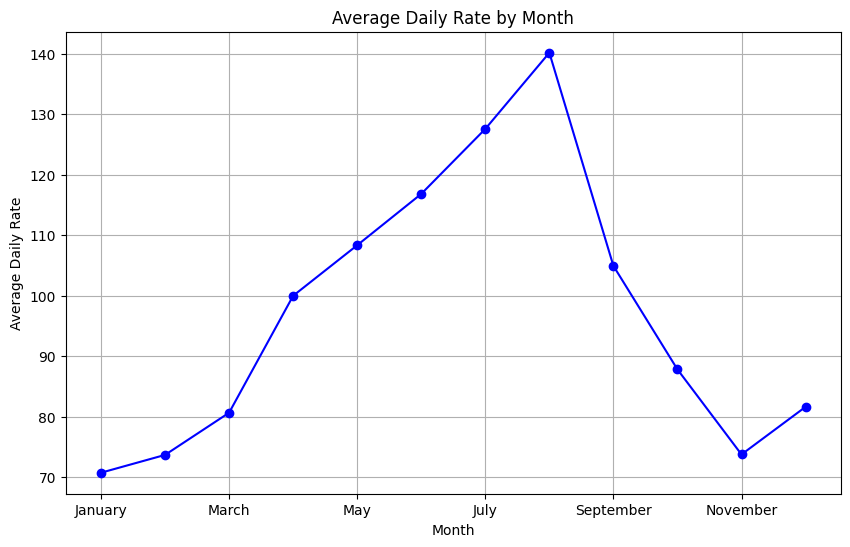

In [ ]:
plt.figure(figsize=(10, 6))
monthly_adr.plot(kind='line', marker='o', color='b')
plt.title('Average Daily Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate')
plt.grid(True)
plt.show()

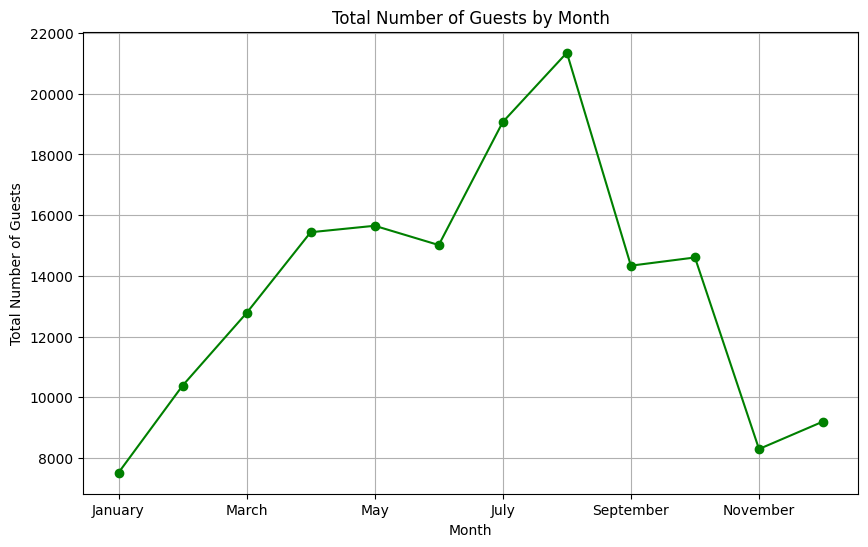

In [ ]:
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)
monthly_guests = df.groupby('arrival_date_month')['total_guests'].sum().sort_index()

#plot
plt.figure(figsize=(10, 6))
monthly_guests.plot(kind='line', marker='o', color='g')
plt.title('Total Number of Guests by Month')
plt.xlabel('Month')
plt.ylabel('Total Number of Guests')
plt.grid(True)
plt.show()

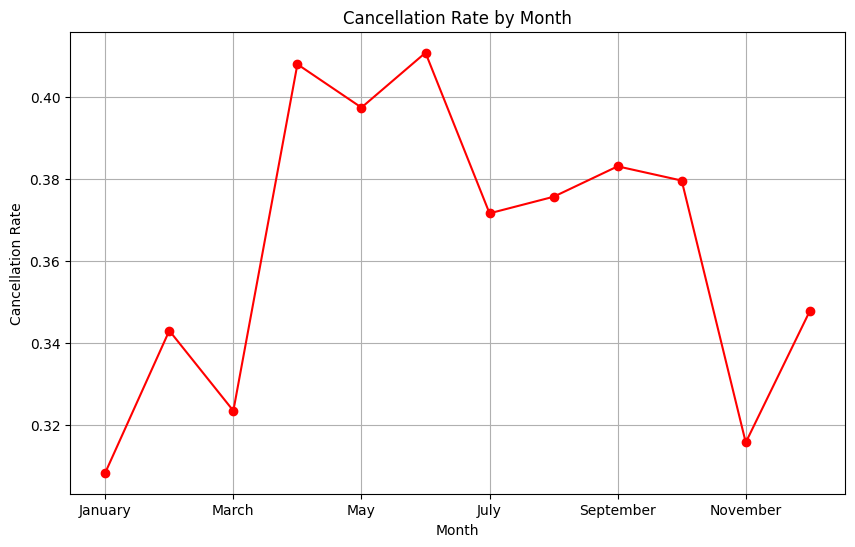

In [ ]:
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)
monthly_cancellation_rate = df.groupby('arrival_date_month').apply(lambda x: (x['is_canceled'].sum() / len(x)))

plt.figure(figsize=(10, 6))
monthly_cancellation_rate.plot(kind='line', marker='o', color='r')
plt.title('Cancellation Rate by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.grid(True)
plt.show()

**Insights:**

The average price per room varies by room type, with it generally being higher during the summer months. This increase in price is largely driven by higher demand, as many people travel during summer breaks, school vacations, and peak tourism seasons.

However, during spring season, there is a notable increase in cancellation rates. This could be due to factors like unpredictable weather or changes in travel plans.


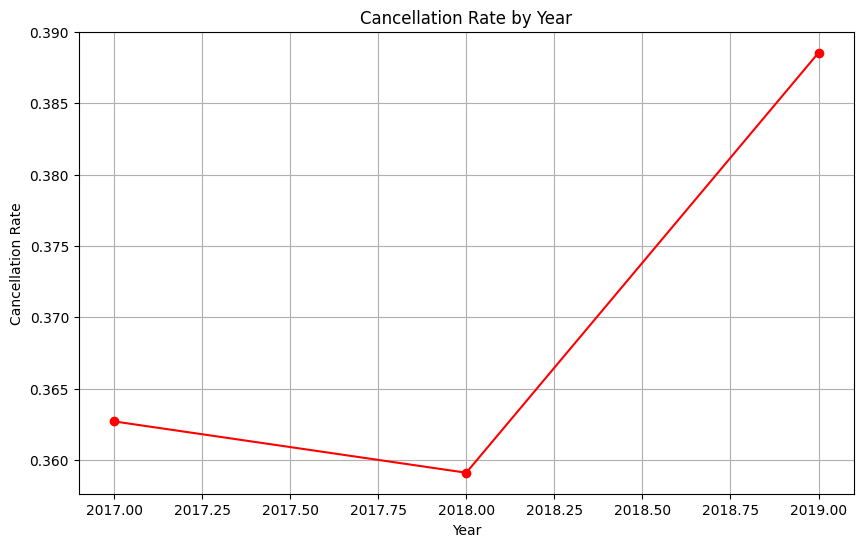

In [ ]:
yearly_cancellation_rate = df.groupby('arrival_date_year').apply(lambda x: (x['is_canceled'].sum() / len(x)))

plt.figure(figsize=(10, 6))
yearly_cancellation_rate.plot(kind='line', marker='o', color='r')
plt.title('Cancellation Rate by Year')
plt.xlabel('Year')
plt.ylabel('Cancellation Rate')
plt.grid(True)
plt.show()

**Insight:**

2019 was the start of the pandemic, hence there was increase in hotel cancellations.

### Proportion of Booking Cancellations

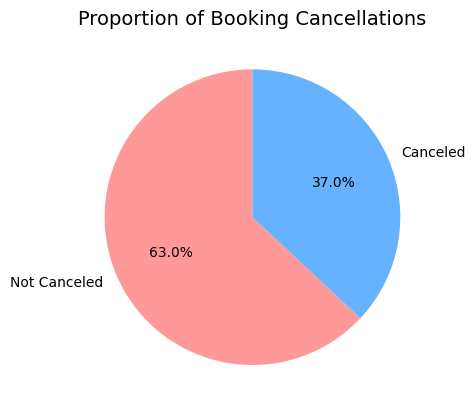

In [ ]:
cancel_count = df['is_canceled'].value_counts().reset_index()

plt.pie(x=cancel_count['count'], labels =['Not Canceled', 'Canceled'], autopct = '%1.1f%%', startangle = 90, colors=['#FF9999','#66B2FF'])
plt.title('Proportion of Booking Cancellations', fontsize=14)
plt.show()

**Insight:**

Although there is a low cancellation rate of 37.0% compared to 63.0% non-cancellations, indicating most bookings are fulfilled, it is still significant enough to impact revenue and operations. There may be underlying issues, such as customer uncertainty.

### Categorical Variables vs. Cancellation Rate

In [ ]:
categorical = df.select_dtypes(include='object')
categorical.columns

Index(['meal', 'country', 'market_segment', 'distribution_channel',
       'reserved_room_type', 'assigned_room_type', 'deposit_type',
       'customer_type', 'reservation_status', 'reservation_status_date'],
      dtype='object')

Total Countries in the dataset: 165


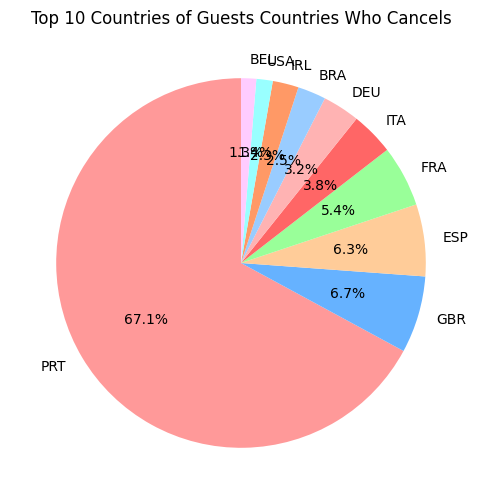

In [ ]:
df1 = df.loc[df.is_canceled == 1, :].copy()
countries = df1.groupby('country')['total_guests'].sum()

print("Total Countries in the dataset:", df['country'].nunique())

top_10_countries = countries.sort_values(ascending=False).head(10)
total_guests = top_10_countries.values
country_names = top_10_countries.index

plt.figure(figsize=(6, 6))
plt.pie(total_guests, labels=country_names, autopct='%1.1f%%', startangle=90, colors = ['#FF9999', '#66B2FF', '#FFCC99', '#99FF99', '#FF6666',
          '#FFB3B3', '#99CCFF', '#FF9966', '#99FFFF', '#FFCCFF'])
plt.title('Top 10 Countries of Guests Countries Who Cancels')
plt.show()

**Insight:**

A very large portion of the customers who cancel is from Portugal and other European countries. This could reflect economic or political situations in the country which needs to be investigated further.

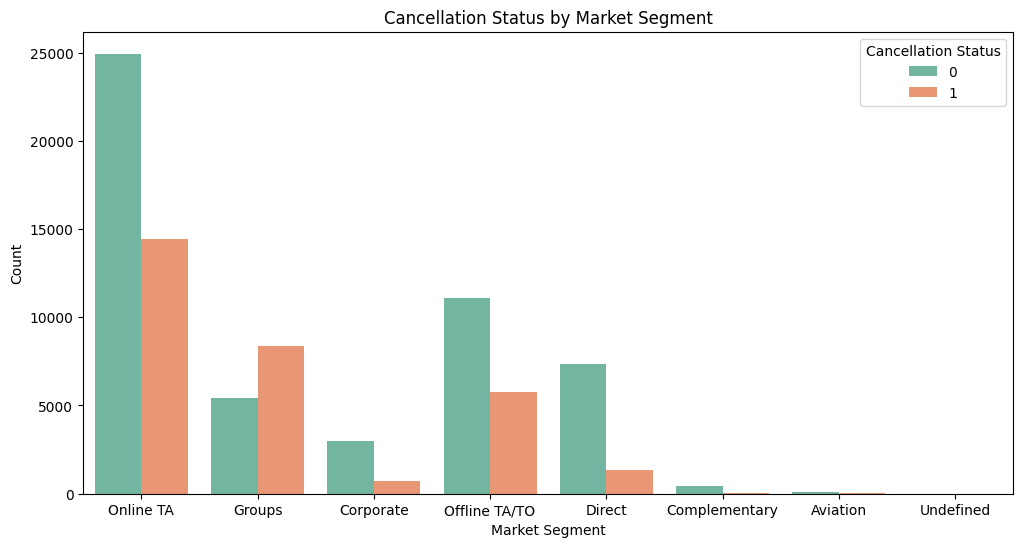

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df, x='market_segment', hue='is_canceled', palette = 'Set2')
plt.title('Cancellation Status by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')
plt.show()

**Insight:**

Groups market segment has a higher chance of cancelling than other market segments, likely due to the clashing complexity of group travel plans. Hotels can try to mitigate this by trying to providing flexible options for the group.

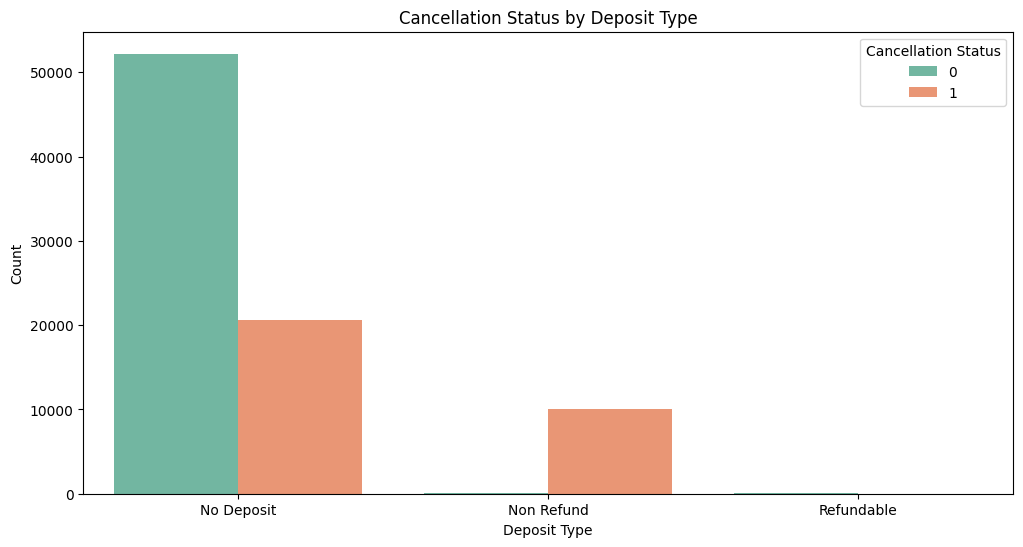

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df, x='deposit_type', hue='is_canceled', palette = 'Set2')
plt.title('Cancellation Status by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')
plt.show()

**Insight:**

Customers who paid either a refundable or non-refundable deposit type tend to have higher cancellation rates. "No Deposit" may often be part of guaranteed stays or reservations closer to the travel date.

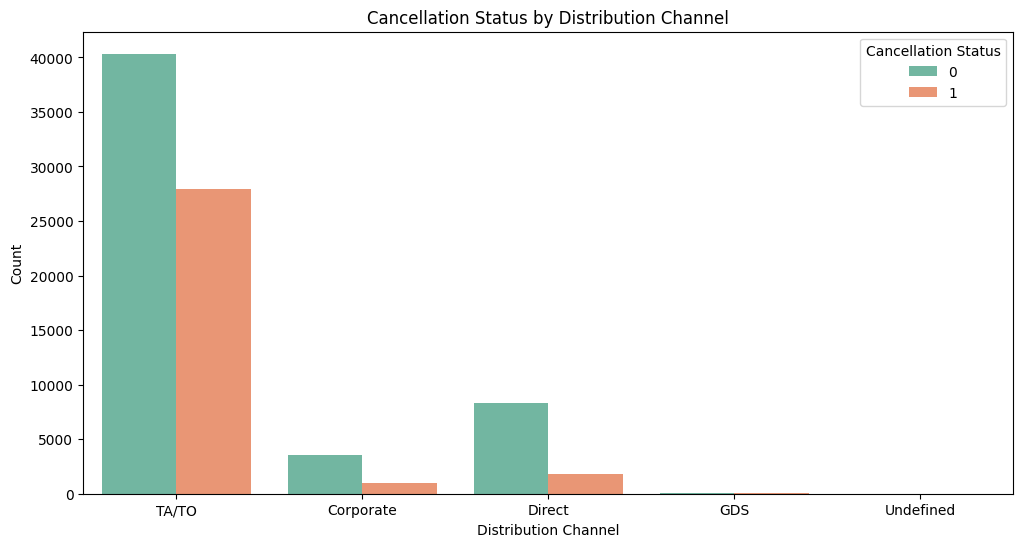

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df, x='distribution_channel', hue='is_canceled', palette = 'Set2')
plt.title('Cancellation Status by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')
plt.show()

**Insight:**

Distribution channel does not really affect cancellation status.

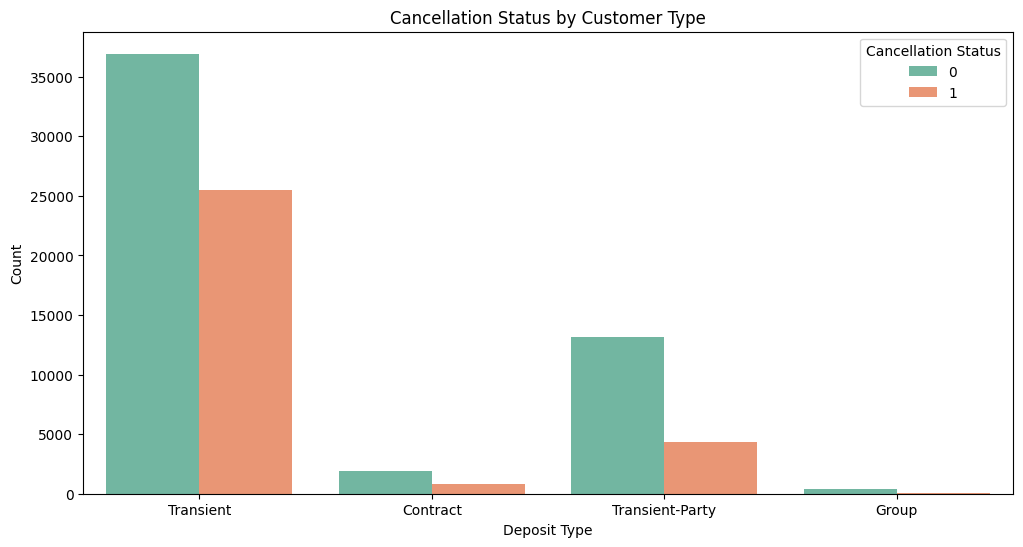

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df, x='customer_type', hue='is_canceled', palette = 'Set2')
plt.title('Cancellation Status by Customer Type')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')
plt.show()

**Insight:**

Customer type does not really affect cancellation status.

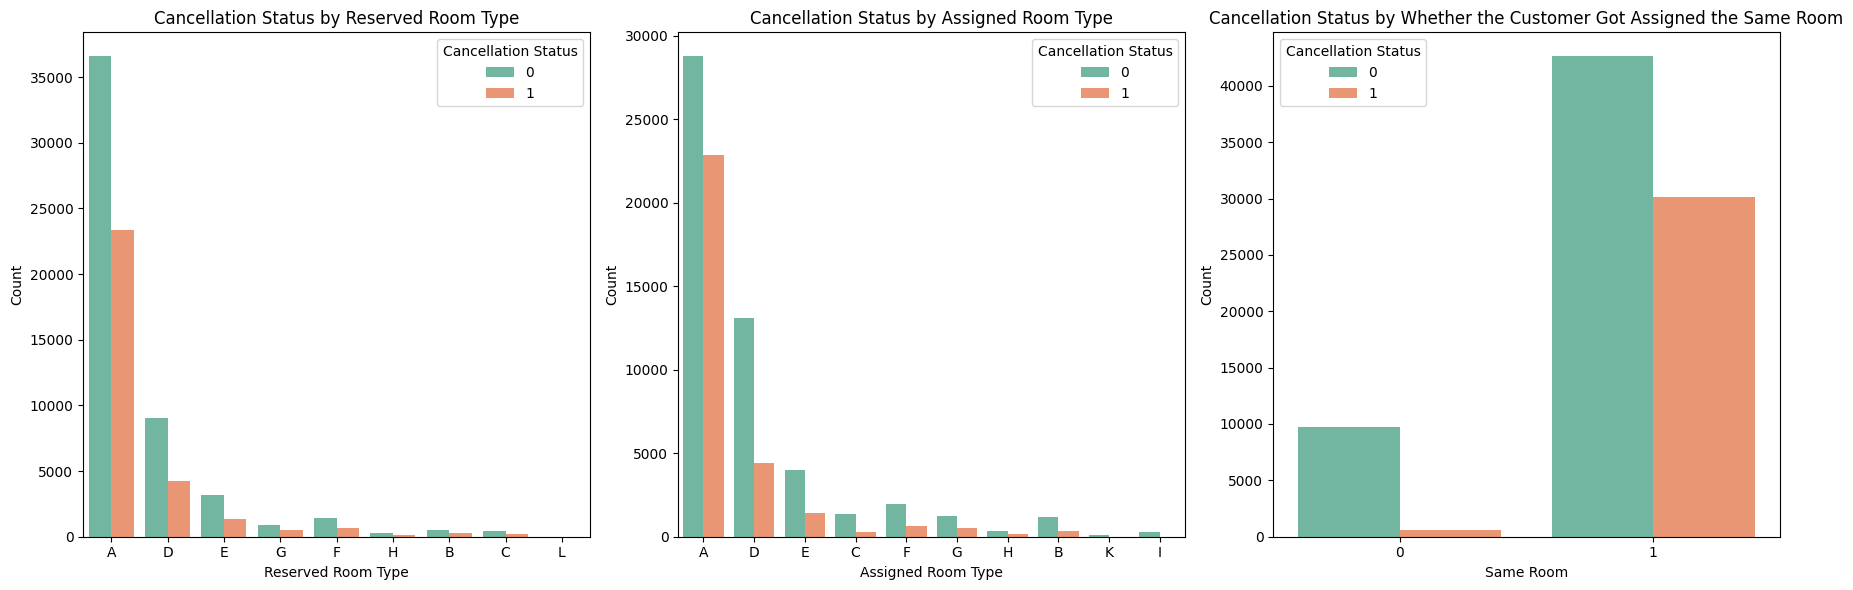

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='reserved_room_type', hue='is_canceled', palette='Set2')
plt.title('Cancellation Status by Reserved Room Type')
plt.xlabel('Reserved Room Type')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='assigned_room_type', hue='is_canceled', palette='Set2')
plt.title('Cancellation Status by Assigned Room Type')
plt.xlabel('Assigned Room Type')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='same_room', hue='is_canceled', palette='Set2')
plt.title('Cancellation Status by Whether the Customer Got Assigned the Same Room')
plt.xlabel('Same Room')
plt.ylabel('Count')
plt.legend(title='Cancellation Status')

plt.tight_layout()
plt.show()

**Insight:**

The room type does not really affect cancellation status.

### Numerical Variables vs. Cancellation Rate

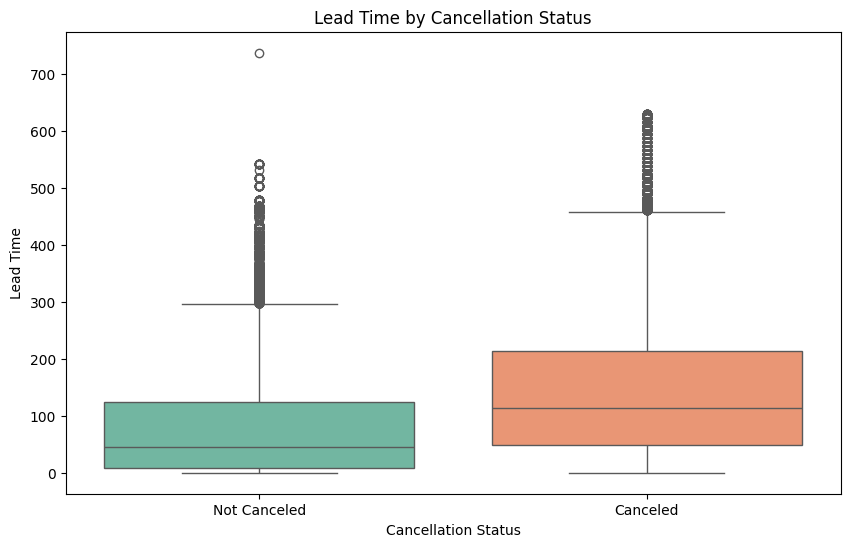

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set2')
plt.title('Lead Time by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Lead Time')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

**Insight:**

Customers who cancel have longer lead times as bookings made far in advance are more prone to changes or cancellations due to evolving plans or unforeseen circumstances.

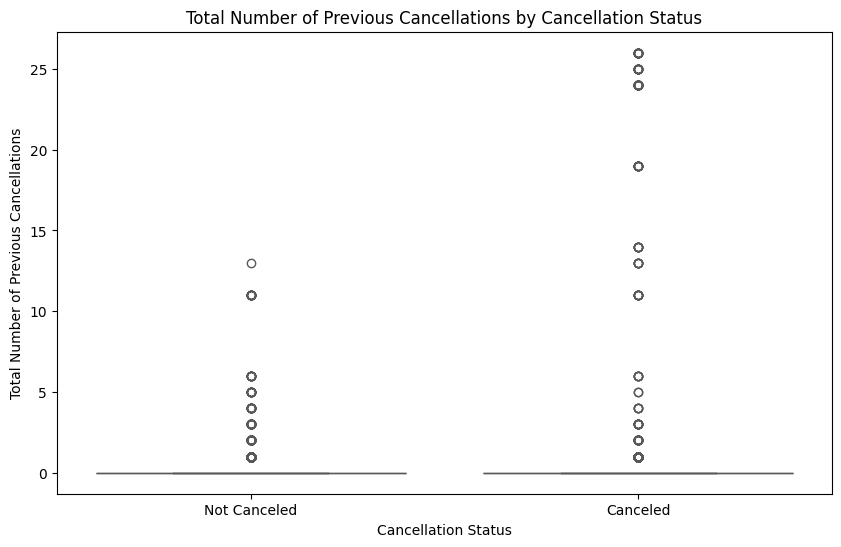

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_canceled', y='previous_cancellations', palette='Set2')
plt.title('Total Number of Previous Cancellations by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Previous Cancellations')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

Since the data is highly skewed, we can use countplot while transforming the y-axis to a logarithmic scale, which compresses the higher values and expands the lower ones, to make the smaller categories more visible.

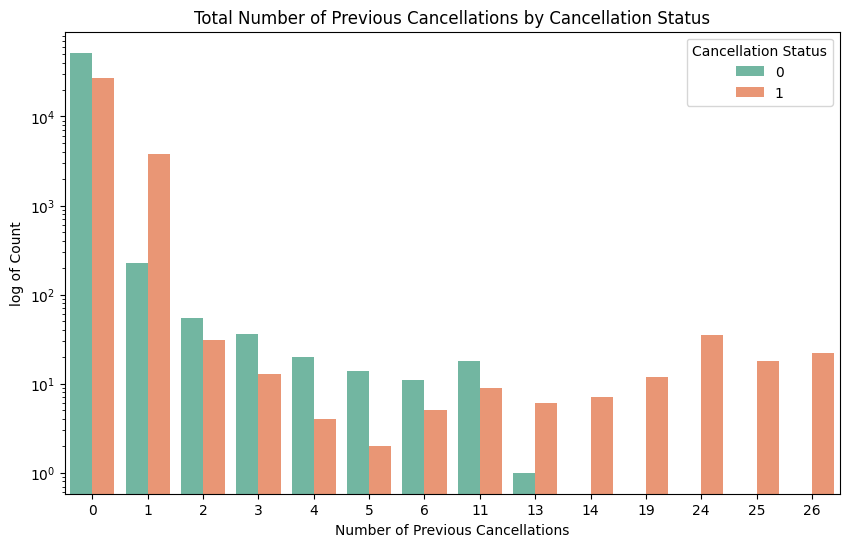

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='previous_cancellations', hue='is_canceled', palette='Set2')
plt.title('Total Number of Previous Cancellations by Cancellation Status')
plt.xlabel('Number of Previous Cancellations')
plt.ylabel('log of Count')
plt.yscale('log')
plt.legend(title='Cancellation Status')

plt.show()

**Insight:**

The higher the number of previous cancellations, the more chances of booking cancellation now too. This pattern may be due to a lack of commitment from these customers or frequent changes in their travel plans.

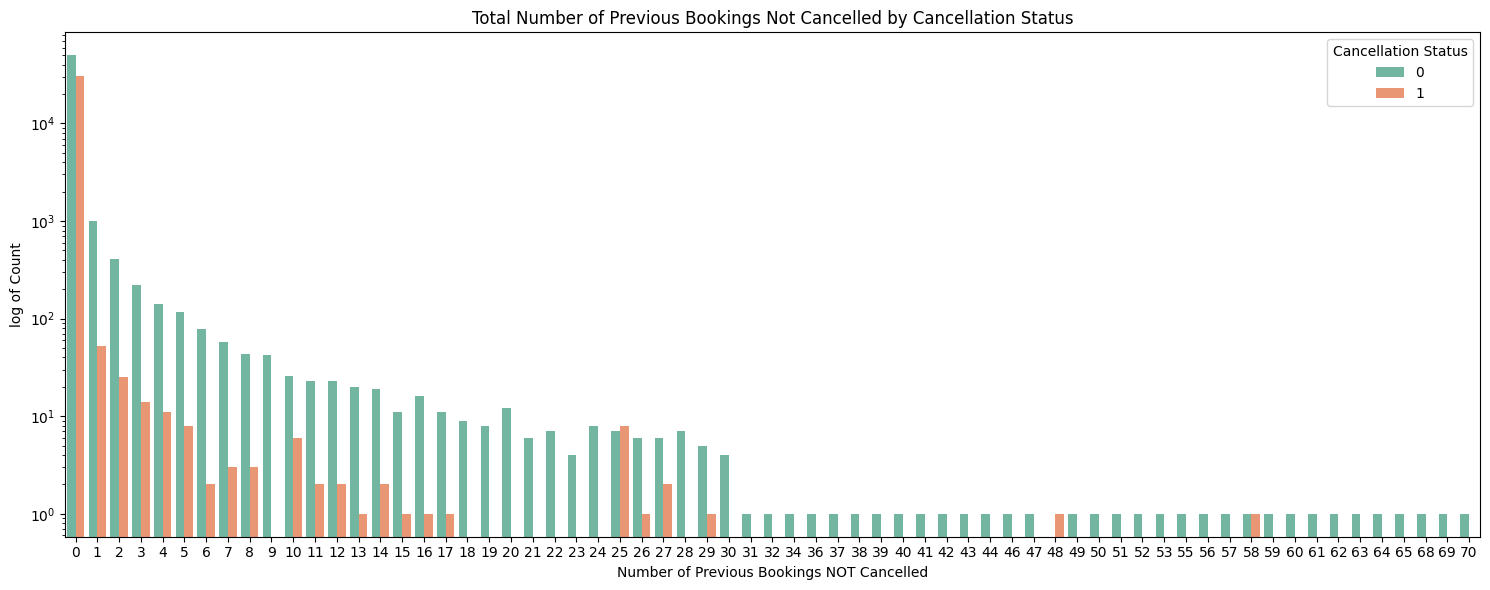

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='previous_bookings_not_canceled', hue='is_canceled', palette='Set2')
plt.title('Total Number of Previous Bookings Not Cancelled by Cancellation Status')
plt.xlabel('Number of Previous Bookings NOT Cancelled')
plt.ylabel('log of Count')
plt.yscale('log')
plt.legend(title='Cancellation Status')

plt.tight_layout()
plt.show()

**Insight:**

The total number of previous bookings not cancelled may be a weak indicator. There is a small negative correlation. The more bookings not cancelled previously, the less likely the booking will be cancelled now.

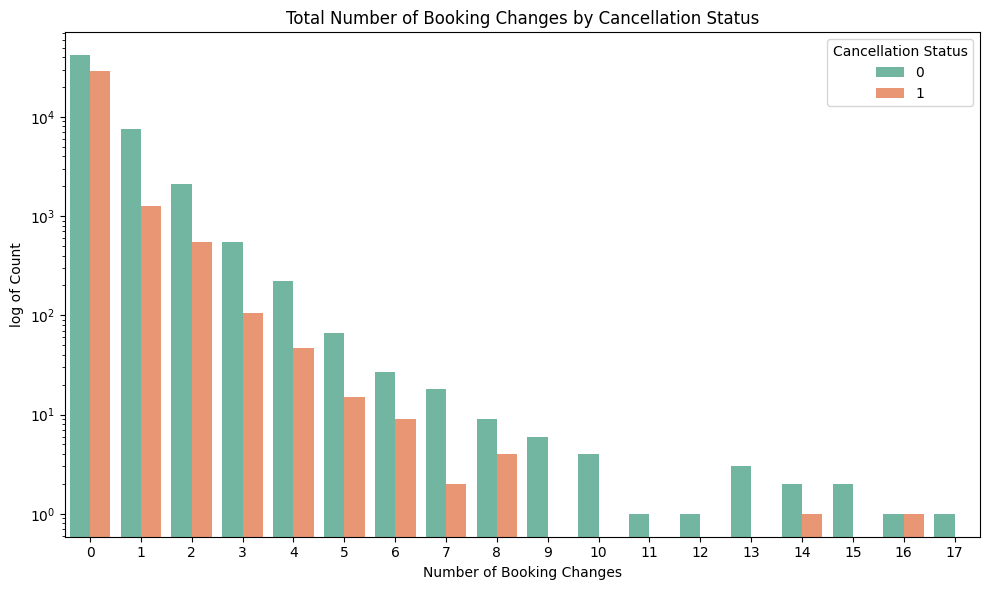

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='booking_changes', hue='is_canceled', palette='Set2')
plt.title('Total Number of Booking Changes by Cancellation Status')
plt.xlabel('Number of Booking Changes')
plt.ylabel('log of Count')
plt.yscale('log')
plt.legend(title='Cancellation Status')

plt.tight_layout()
plt.show()

**Insight:**

The total number of bookings changes may also be a weak indicator. There is a small negative correlation. The more bookings nchanges made, the less likely the booking will be cancelled.

In [ ]:
df['days_in_waiting_list'].describe()

,days_in_waiting_list
count,83098.000000
mean,2.341175
std,17.814518
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,391.000000


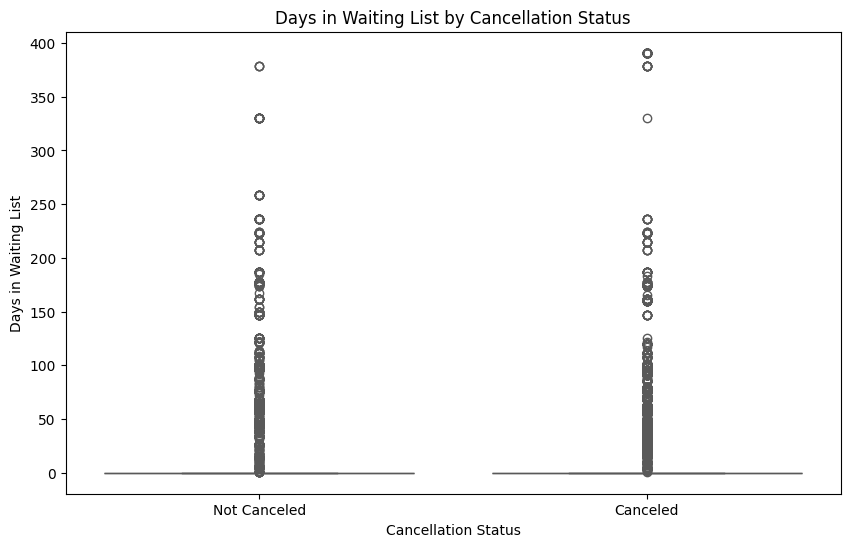

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_canceled', y='days_in_waiting_list', palette='Set2')
plt.title('Days in Waiting List by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Days in Waiting List')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

**Insight:**

Days in Waiting List is not really indicative of the cancellation status.

In [ ]:
df[df['is_canceled']==0]['adr'].describe()

,adr
count,52369.000000
mean,100.195975
std,49.068431
min,0.000000
25%,68.000000
50%,93.000000
75%,125.000000
max,508.000000


In [ ]:
df[df['is_canceled']==1]['adr'].describe()

,adr
count,30729.000000
mean,104.753646
std,45.931835
min,0.000000
25%,72.250000
50%,96.000000
75%,127.200000
max,450.000000


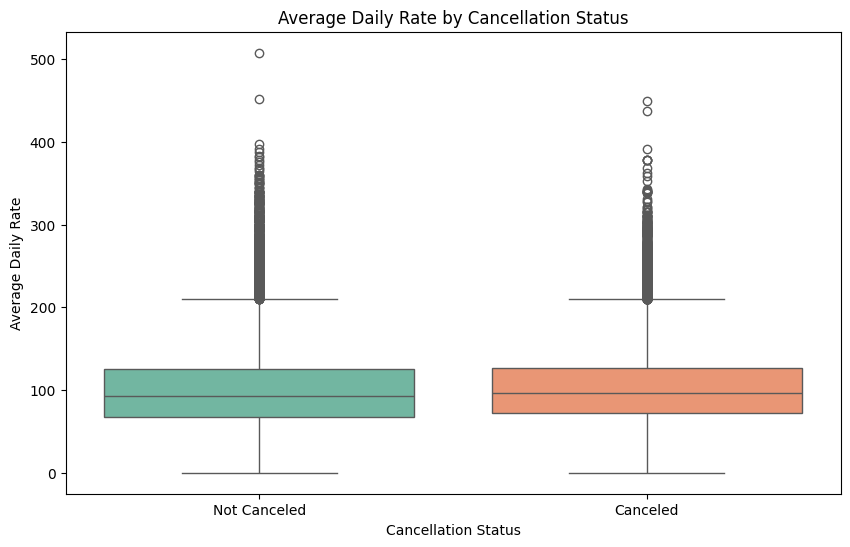

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_canceled', y='adr', palette='Set2')
plt.title('Average Daily Rate by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Average Daily Rate')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

**Insight:**

Customers who cancel tend to have slightly higher daily rates, which could indicate that premium bookings or higher-priced packages are more susceptible to cancellation.

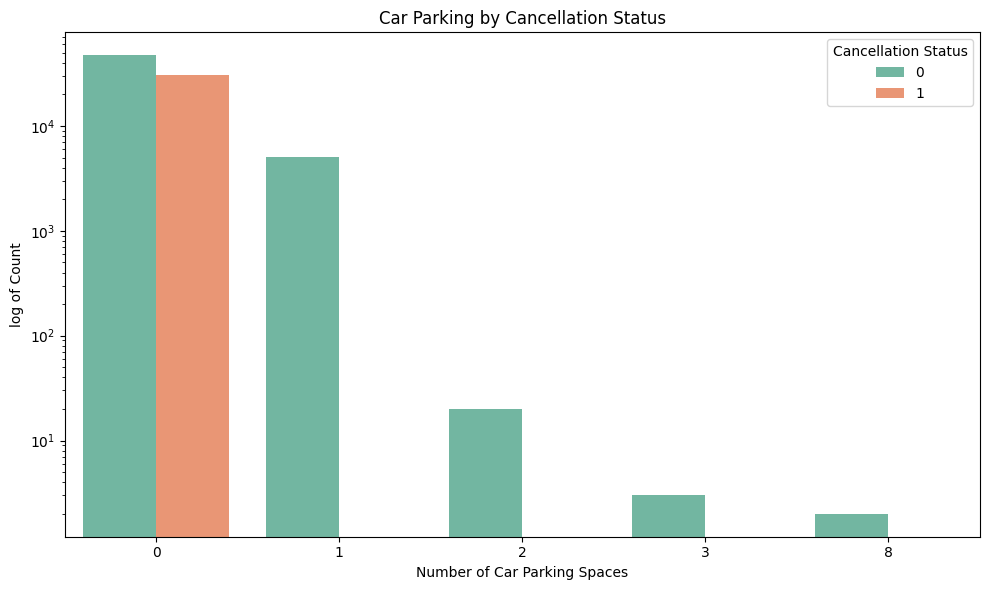

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='required_car_parking_spaces', hue='is_canceled', palette='Set2')
plt.title('Car Parking by Cancellation Status')
plt.xlabel('Number of Car Parking Spaces')
plt.ylabel('log of Count')
plt.yscale('log')
plt.legend(title='Cancellation Status')

plt.tight_layout()
plt.show()

**Insight:**

Number of required car parking spaces is not really indicative of cancellation status.

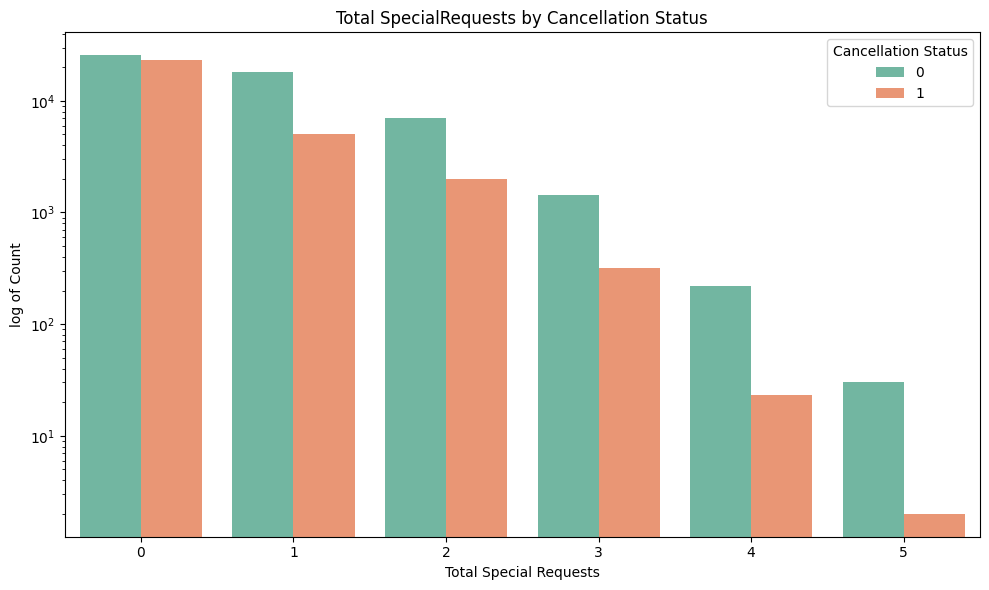

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='total_of_special_requests', hue='is_canceled', palette='Set2')
plt.title('Total SpecialRequests by Cancellation Status')
plt.xlabel('Total Special Requests')
plt.ylabel('log of Count')
plt.yscale('log')
plt.legend(title='Cancellation Status')

plt.tight_layout()
plt.show()

**Insight:**

Number of total special requests is not really indicative of cancellation status.

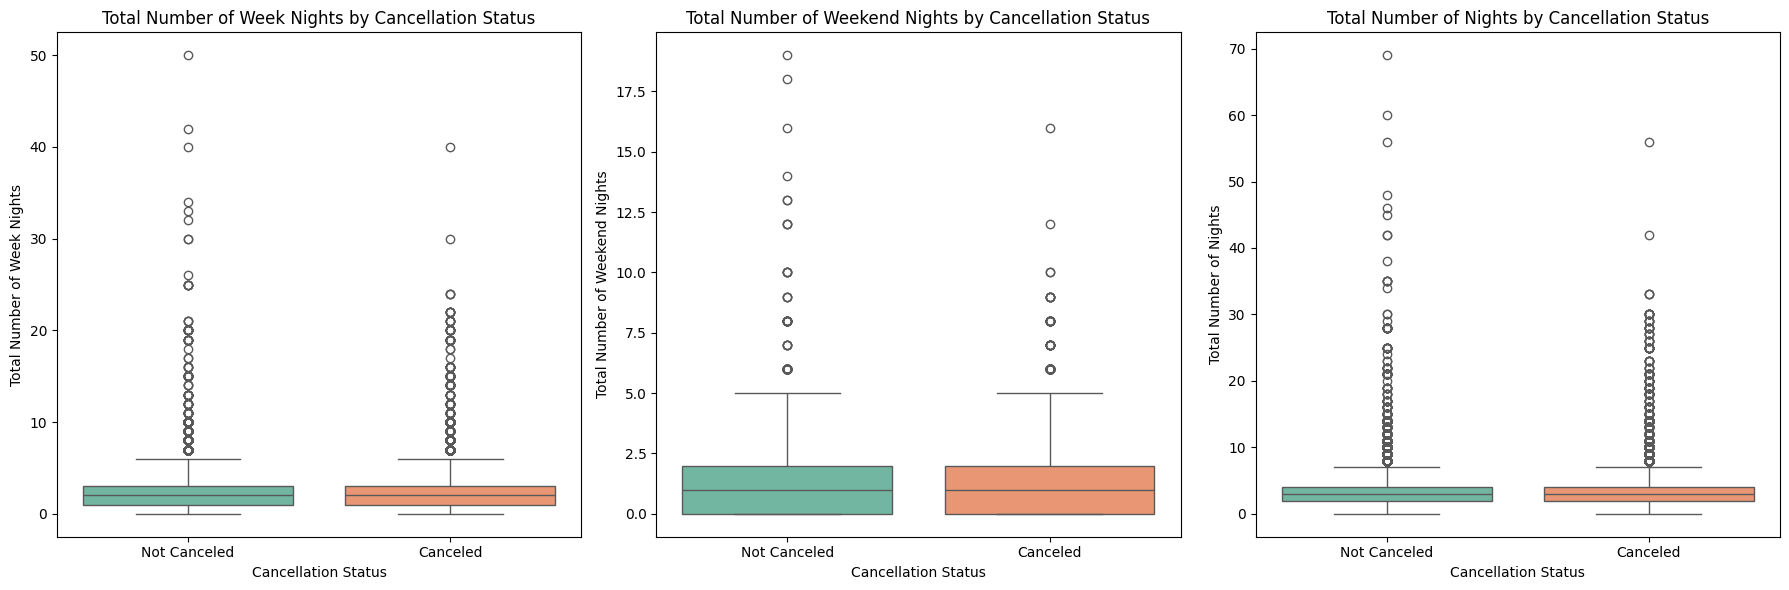

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='is_canceled', y='stays_in_week_nights', palette='Set2')
plt.title('Total Number of Week Nights by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Week Nights')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='is_canceled', y='stays_in_weekend_nights', palette='Set2')
plt.title('Total Number of Weekend Nights by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Weekend Nights')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='is_canceled', y='total_nights', palette='Set2')
plt.title('Total Number of Nights by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Nights')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.tight_layout()
plt.show()

**Insight:**

The total number of nights stayed or booked might only be a weak indicator of cancellation status.

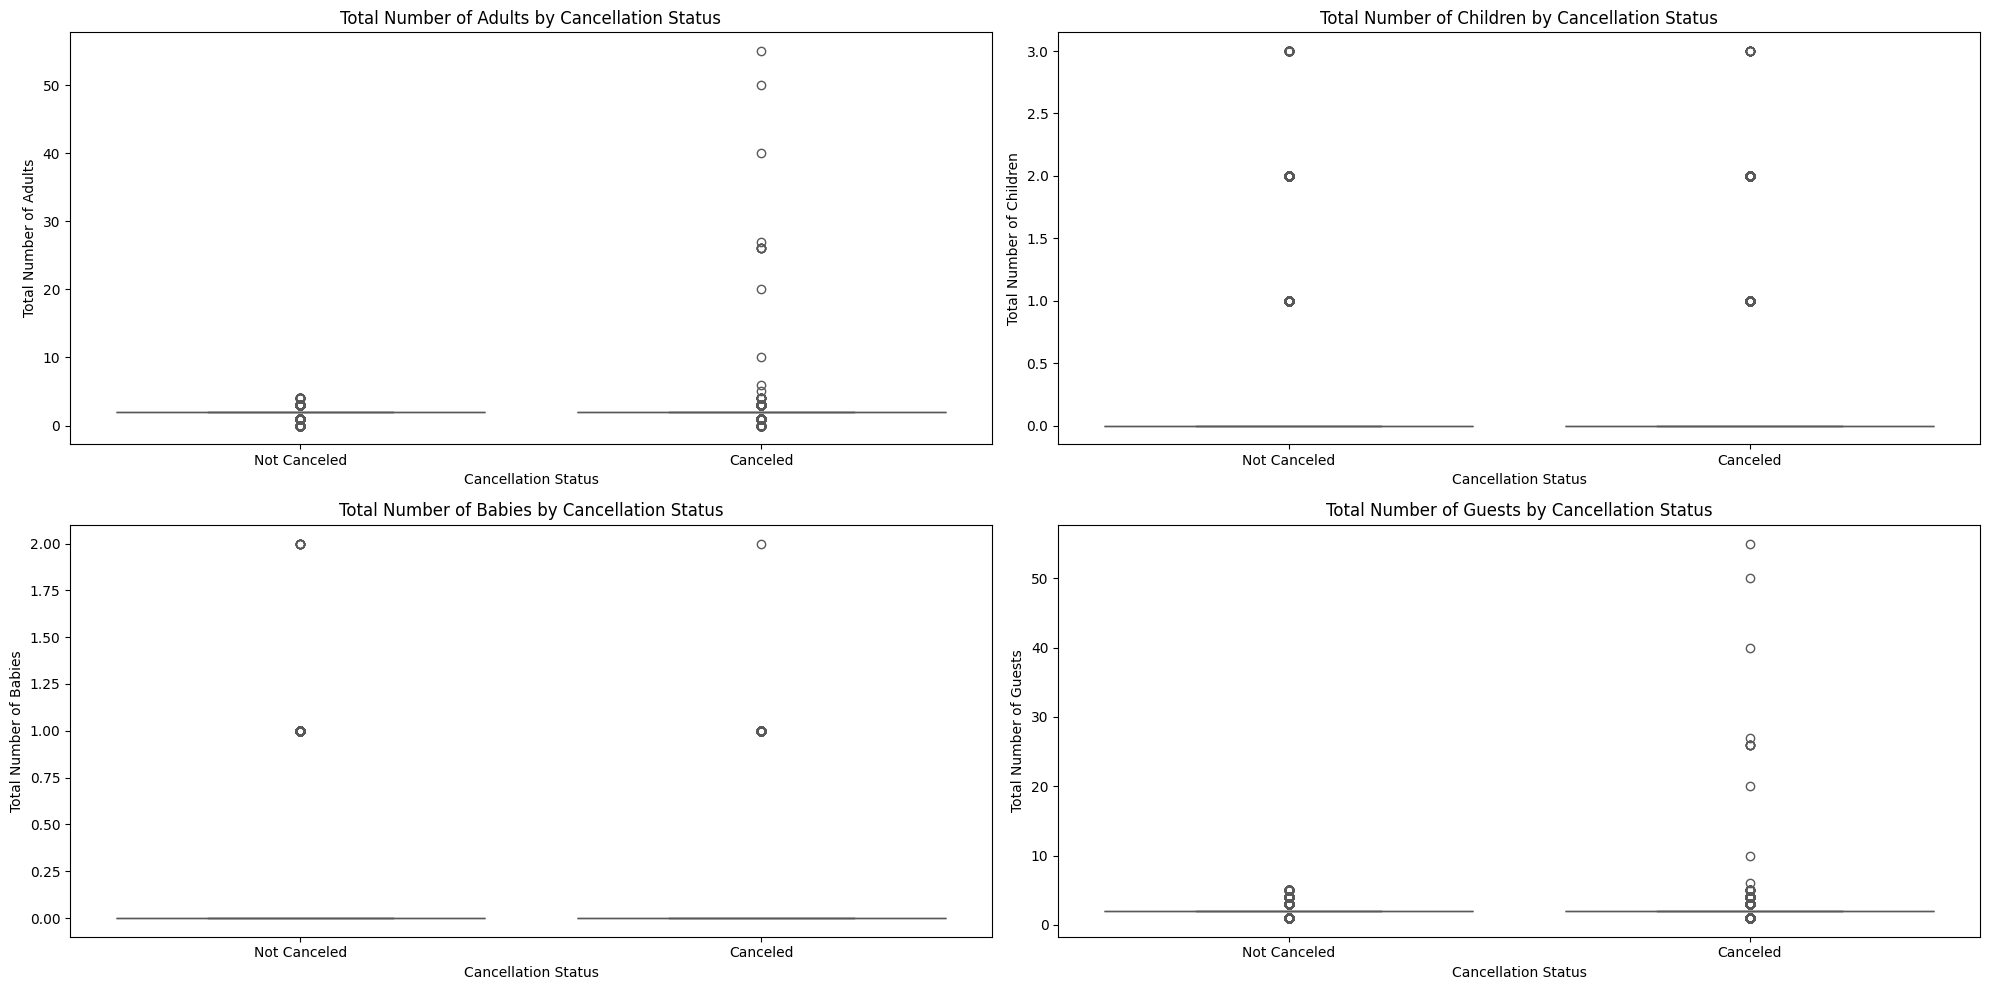

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='is_canceled', y='adults', palette='Set2')
plt.title('Total Number of Adults by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Adults')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='is_canceled', y='children', palette='Set2')
plt.title('Total Number of Children by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Children')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='is_canceled', y='babies', palette='Set2')
plt.title('Total Number of Babies by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Babies')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='is_canceled', y='total_guests', palette='Set2')
plt.title('Total Number of Guests by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Number of Guests')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])

plt.tight_layout()
plt.show()

**Insight:**

Total number of guests and adults might correlate to cancellation status, but children and babies might contribute very little.

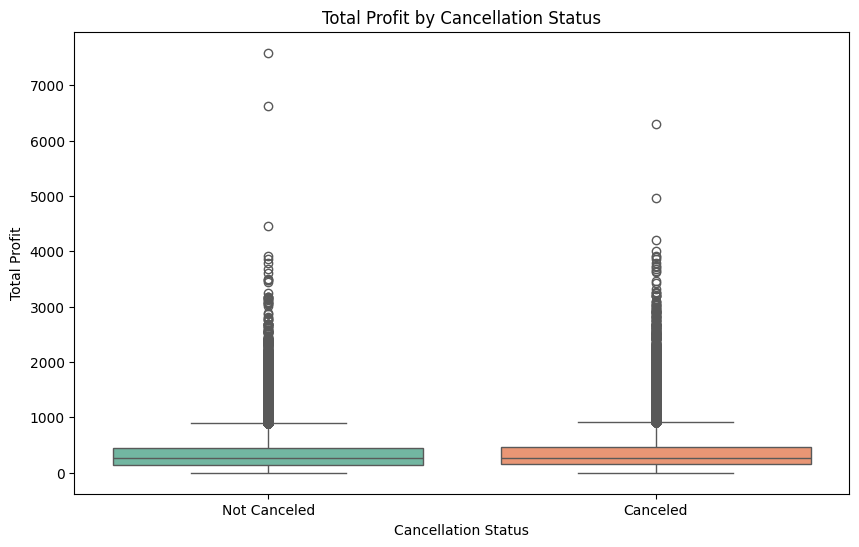

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_canceled', y='profit', palette='Set2')
plt.title('Total Profit by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Profit')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

**Insight:**

The total number of nights is not really indicative of cancellation status.

## Data Preprocessing

### Feature Selection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83098 entries, 0 to 83292
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   is_canceled                     83098 non-null  int64         
 1   lead_time                       83098 non-null  int64         
 2   arrival_date_year               83098 non-null  int64         
 3   arrival_date_month              83098 non-null  category      
 4   arrival_date_week_number        83098 non-null  int64         
 5   arrival_date_day_of_month       83098 non-null  int64         
 6   stays_in_weekend_nights         83098 non-null  int64         
 7   stays_in_week_nights            83098 non-null  int64         
 8   adults                          83098 non-null  int64         
 9   children                        83098 non-null  float64       
 10  babies                          83098 non-null  int64         
 11  meal   

In [ ]:
print(f'Data Shape: {df.shape}')

Data Shape: (83098, 36)


In [ ]:
df.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'bookingID',
       'total_guests', 'total_nights', 'profit', 'same_room', 'arrival_date'],
      dtype='object')

In [ ]:
#drop uneccesary columns
df = df.drop(columns=['arrival_date_year','arrival_date_month','arrival_date_week_number', 'arrival_date_day_of_month',
                      'country', 'assigned_room_type','bookingID',
                      'reservation_status','reservation_status_date', 'arrival_date'], axis = 1)

- The arrival information, can also be dropped because that indicates a booking is not canceled.
- The `bookingID` and `country` coulumns can be dropped as they only contain identification and are therefore irrelevant to the prediction.
- The `assigned_room_type` column is dropped, as a room is only assigned when a guest checks in which means a booking is not canceled.
- The `reservation_status` and `reservation_status_date` contain information about the target variable which causes data leakage, so it needs to be dropped.

In [ ]:
numerical_df = df.select_dtypes(include='number')

In [ ]:
X = numerical_df.copy()
X['constant'] = 1

#calculate VIF scores
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values(by='VIF', ascending=False)

print(vif_data)

                          Variable        VIF
2          stays_in_weekend_nights        inf
3             stays_in_week_nights        inf
4                           adults        inf
5                         children        inf
6                           babies        inf
17                    total_nights        inf
16                    total_guests        inf
20                        constant  27.355573
18                          profit   6.509670
13                             adr   3.124459
7                is_repeated_guest   1.293260
0                      is_canceled   1.272492
9   previous_bookings_not_canceled   1.260121
1                        lead_time   1.212927
15       total_of_special_requests   1.135327
19                       same_room   1.111401
11                           agent   1.077445
14     required_car_parking_spaces   1.074791
10                 booking_changes   1.051326
8           previous_cancellations   1.050740
12            days_in_waiting_list

The `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `total_nights`, `total_guests`, `profit` and `adr` are multicollinerated. Some of these columns need to be dropped to avoid overrepresentation.

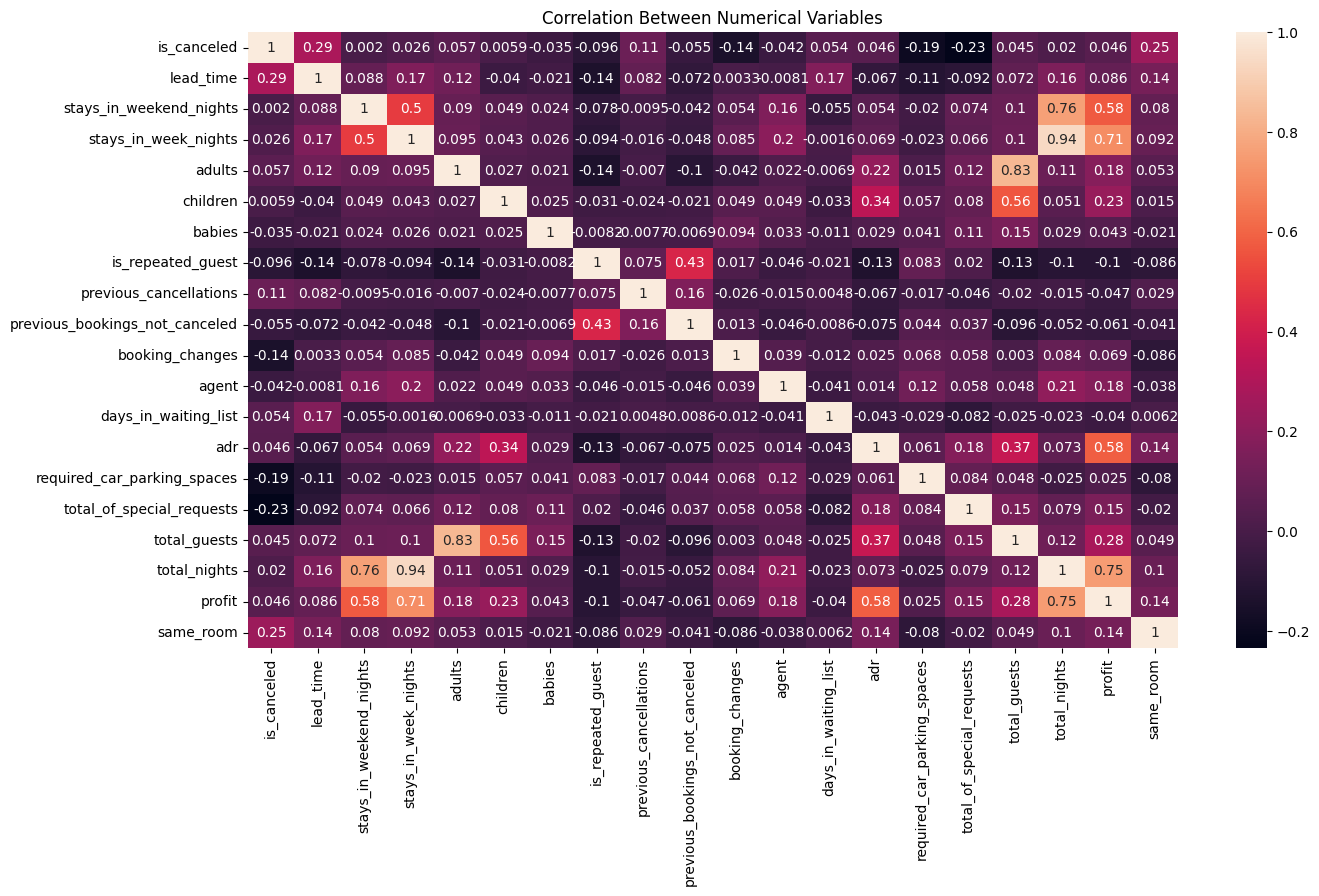

In [ ]:
#check correlation
plt.figure(figsize = (15, 8))
corr = numerical_df.corr()
sns.heatmap(corr, annot = True)
plt.title('Correlation Between Numerical Variables')
plt.show()

In [ ]:
#drop correlated variables
df = df.drop(columns=['stays_in_week_nights','stays_in_weekend_nights','adults','children','babies', 'profit'], axis = 1)

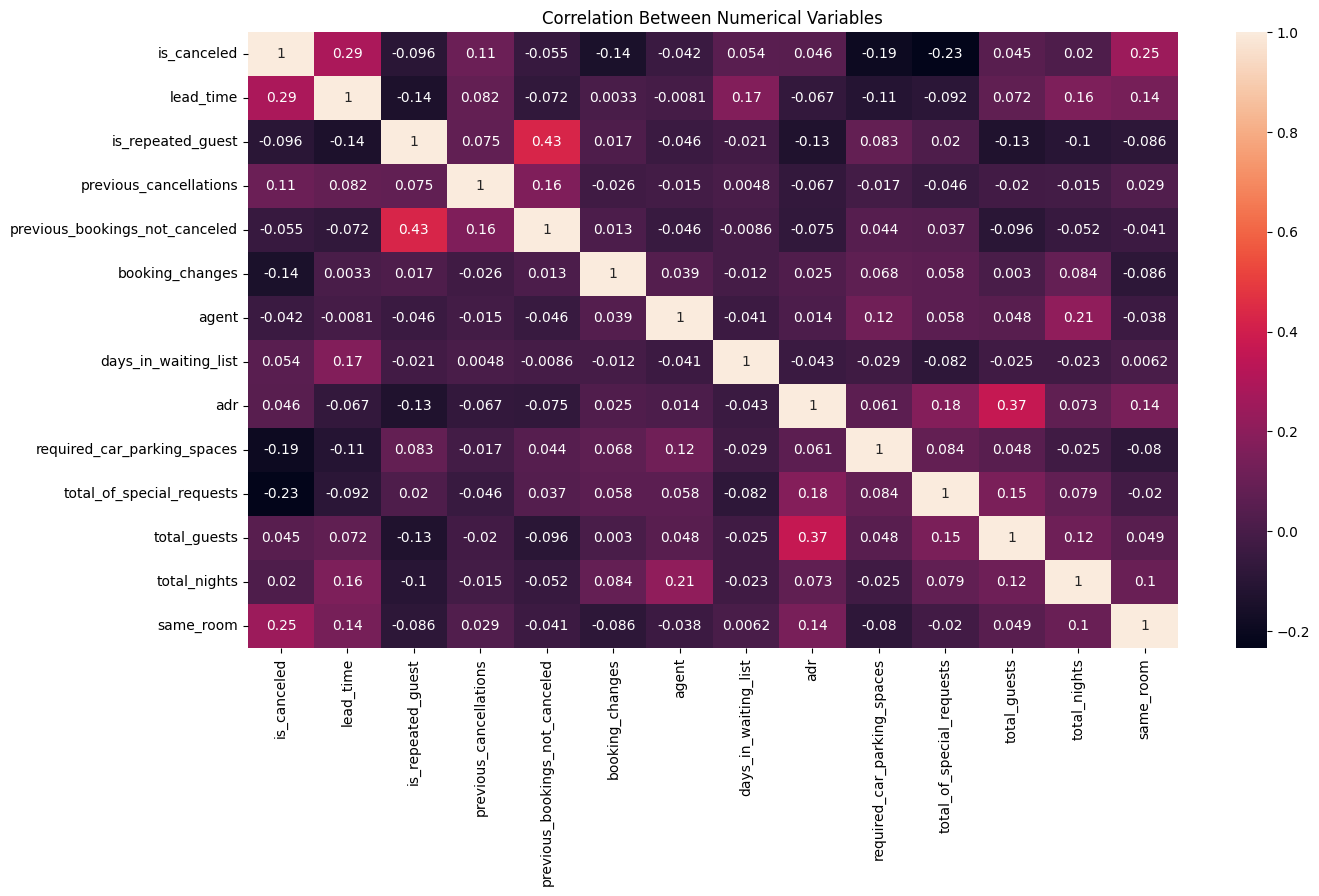

In [ ]:
#check
numerical_df = df.select_dtypes(include='number')

plt.figure(figsize = (15, 8))
corr = numerical_df.corr()
sns.heatmap(corr, annot = True)
plt.title('Correlation Between Numerical Variables')
plt.show()

In [ ]:
X = numerical_df.copy()
X['constant'] = 1

vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values(by='VIF', ascending=False)

print(vif_data)

                          Variable        VIF
14                        constant  17.625103
2                is_repeated_guest   1.280448
0                      is_canceled   1.271362
4   previous_bookings_not_canceled   1.259454
8                              adr   1.242481
1                        lead_time   1.202975
11                    total_guests   1.202114
10       total_of_special_requests   1.126341
12                    total_nights   1.115672
13                       same_room   1.110019
9      required_car_parking_spaces   1.073932
6                            agent   1.072674
3           previous_cancellations   1.050422
7             days_in_waiting_list   1.039280
5                  booking_changes   1.038918


In [ ]:
#check statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,83098.0,0.369792,0.482751,0.0,0.0,0.00,1.0,1.0
lead_time,83098.0,104.047594,106.912851,0.0,18.0,69.00,160.0,737.0
is_repeated_guest,83098.0,0.029796,0.170026,0.0,0.0,0.00,0.0,1.0
previous_cancellations,83098.0,0.086885,0.863827,0.0,0.0,0.00,0.0,26.0
previous_bookings_not_canceled,83098.0,0.141712,1.555358,0.0,0.0,0.00,0.0,70.0
booking_changes,83098.0,0.220595,0.641153,0.0,0.0,0.00,0.0,17.0
agent,83098.0,75.051036,107.293615,0.0,7.0,9.00,154.0,535.0
days_in_waiting_list,83098.0,2.341175,17.814518,0.0,0.0,0.00,0.0,391.0
adr,83098.0,101.881366,47.982657,0.0,70.0,94.97,126.0,508.0
required_car_parking_spaces,83098.0,0.061855,0.245102,0.0,0.0,0.00,0.0,8.0


### Encoding of Categorical Variables

In [ ]:
#categorical variables
categorical_df = df.select_dtypes(include='object')
for col in categorical_df.columns:
    print(f'{col}: \n{categorical_df[col].unique()}\n')

meal: 
['BB' 'HB' 'SC' 'FB' 'Undefined']

market_segment: 
['Online TA' 'Groups' 'Corporate' 'Offline TA/TO' 'Direct' 'Complementary'
 'Aviation' 'Undefined']

distribution_channel: 
['TA/TO' 'Corporate' 'Direct' 'GDS' 'Undefined']

reserved_room_type: 
['A' 'D' 'E' 'G' 'F' 'H' 'B' 'C' 'L']

deposit_type: 
['No Deposit' 'Non Refund' 'Refundable']

customer_type: 
['Transient' 'Contract' 'Transient-Party' 'Group']



In [ ]:
#one-hot encoding for the others
df_encoded = pd.get_dummies(df, columns=categorical_df.columns)

### Train test Split

In [ ]:
#features
X = df_encoded.drop(['is_canceled'], axis = 1)
#target
y = df_encoded['is_canceled']

In [ ]:
#split into training and validation data (for testing later)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)  #80% train, 20% validation

In [ ]:
y_train.value_counts()

,count
is_canceled,
0,41929
1,24549


### Outlier Removal

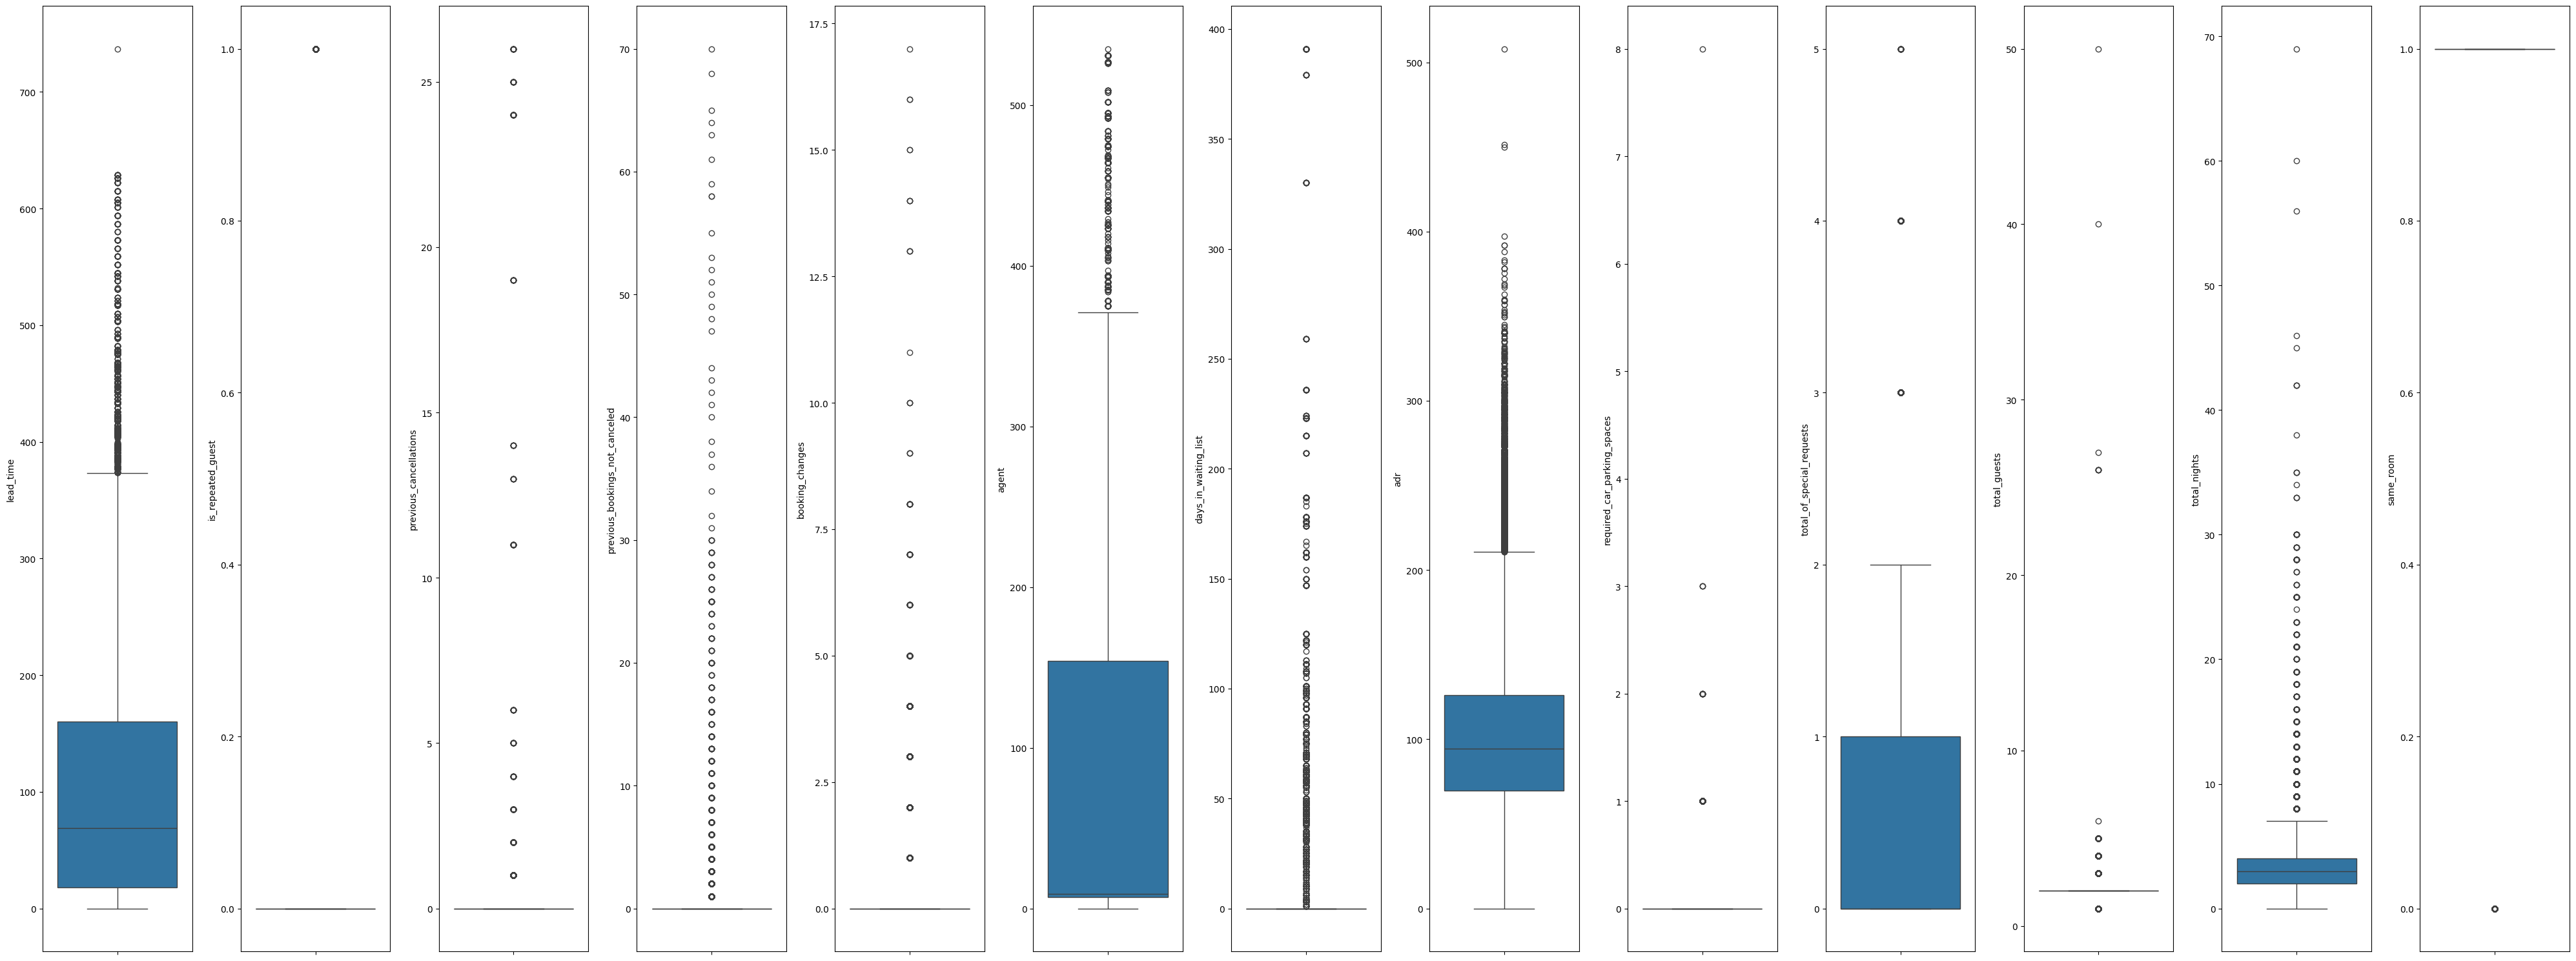

In [ ]:
numerical_cols = numerical_df.columns.drop('is_canceled')

fig, axes = plt.subplots(1,len(numerical_cols), figsize=(40, 15))

for i, column in enumerate(numerical_cols):
    sns.boxplot(y=X_train[column], ax=axes[i])

plt.tight_layout()
plt.show()

The boxplot shows some outliers but this may be due to normally high context, we can scale the data for the prediction model instead of removing the outliers.

### SMOTE

In [ ]:
#SMOTE using training data ONLY
from imblearn import over_sampling

X_smote, y_smote = over_sampling.SMOTE().fit_resample(X_train, y_train)

In [ ]:
df_smote = pd.concat([X_smote, y_smote], axis=1)
df_smote.head()

,lead_time,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,same_room,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_A,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,is_canceled
0,45,0,0,7,1,0.0,0,106.0,0,1,1.0,2,1,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,0
1,16,0,0,0,0,0.0,0,48.0,0,0,2.0,3,1,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,1
2,119,0,0,0,0,9.0,0,76.5,0,1,2.0,1,1,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,1
3,320,0,0,0,0,6.0,0,115.0,0,1,2.0,2,1,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,0
4,3,0,0,0,0,9.0,0,103.0,0,1,2.0,1,1,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,0


In [ ]:
#check
df_smote['is_canceled'].value_counts()

,count
is_canceled,
0,41929
1,41929


In [ ]:
#split the SMOTE training data and testing data
X_train_smote, X_test, y_train_smote, y_test = train_test_split(X_smote, y_smote, test_size=0.20, random_state=42) #60% train, 20% test

### Standardization

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

* (X_train_scaled, y_train_smote)
* (X_test_scaled, y_test)




## Model Training and Evaluation

### Logistic Regression

In [ ]:
#define
logreg = LogisticRegression(random_state=42)

#fit
logreg.fit(X_train_scaled, y_train_smote)

#predict
y_pred_train_logreg = logreg.predict(X_train_scaled)
y_pred_train_probs_logreg = logreg.predict_proba(X_train_scaled)[:, 1]

y_pred_test_logreg = logreg.predict(X_test_scaled)
y_pred_test_probs_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#evaluate on train
precision = precision_score(y_train_smote, y_pred_train_logreg, pos_label=1)
recall = recall_score(y_train_smote, y_pred_train_logreg, pos_label=1)
f1 = f1_score(y_train_smote, y_pred_train_logreg, pos_label=1)
roc_auc = roc_auc_score(y_train_smote, y_pred_train_probs_logreg)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.85638
Recall: 0.76768
F1-Score: 0.80961
ROC AUC: 0.89970


In [ ]:
#evaluate on test
precision = precision_score(y_test, y_pred_test_logreg, pos_label=1)
recall = recall_score(y_test, y_pred_test_logreg, pos_label=1)
f1 = f1_score(y_test, y_pred_test_logreg, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_test_probs_logreg)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.85757
Recall: 0.76145
F1-Score: 0.80665
ROC AUC: 0.89890


### Decision Tree

In [ ]:
#define
dt = DecisionTreeClassifier(random_state=42)

#fit
dt.fit(X_train_scaled, y_train_smote)

#predict
y_pred_train_dt = dt.predict(X_train_scaled)
y_pred_train_probs_dt = dt.predict_proba(X_train_scaled)[:, 1]

y_pred_test_dt = dt.predict(X_test_scaled)
y_pred_test_probs_dt = dt.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#evaluate on train
precision = precision_score(y_train_smote, y_pred_train_dt, pos_label=1)
recall = recall_score(y_train_smote, y_pred_train_dt, pos_label=1)
f1 = f1_score(y_train_smote, y_pred_train_dt, pos_label=1)
roc_auc = roc_auc_score(y_train_smote, y_pred_train_probs_dt)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.99495
Recall: 0.99053
F1-Score: 0.99273
ROC AUC: 0.99987


In [ ]:
#evaluate on test
precision = precision_score(y_test, y_pred_test_dt, pos_label=1)
recall = recall_score(y_test, y_pred_test_dt, pos_label=1)
f1 = f1_score(y_test, y_pred_test_dt, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_test_probs_dt)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.84301
Recall: 0.84584
F1-Score: 0.84442
ROC AUC: 0.84890


### Random Forest

In [ ]:
#define
rf = RandomForestClassifier(random_state=42)

#fit
rf.fit(X_train_scaled, y_train_smote)

#predict
y_pred_train_rf = rf.predict(X_train_scaled)
y_pred_train_probs_rf = rf.predict_proba(X_train_scaled)[:, 1]

y_pred_test_rf = rf.predict(X_test_scaled)
y_pred_test_probs_rf = rf.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#evaluate on train
precision = precision_score(y_train_smote, y_pred_train_rf, pos_label=1)
recall = recall_score(y_train_smote, y_pred_train_rf, pos_label=1)
f1 = f1_score(y_train_smote, y_pred_train_rf, pos_label=1)
roc_auc = roc_auc_score(y_train_smote, y_pred_train_probs_rf)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.99306
Recall: 0.99244
F1-Score: 0.99275
ROC AUC: 0.99928


In [ ]:
#evaluate on test
precision = precision_score(y_test, y_pred_test_rf, pos_label=1)
recall = recall_score(y_test, y_pred_test_rf, pos_label=1)
f1 = f1_score(y_test, y_pred_test_rf, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_test_probs_rf)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.89808
Recall: 0.85663
F1-Score: 0.87686
ROC AUC: 0.94839


### XGBoost

In [ ]:
#define
xgb = XGBClassifier(random_state=42)

#fit
xgb.fit(X_train_scaled, y_train_smote)

#predict
y_pred_train_xgb = xgb.predict(X_train_scaled)
y_pred_train_probs_xgb = xgb.predict_proba(X_train_scaled)[:, 1]

y_pred_test_xgb = xgb.predict(X_test_scaled)
y_pred_test_probs_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#evaluate on train
precision = precision_score(y_train_smote, y_pred_train_xgb, pos_label=1)
recall = recall_score(y_train_smote, y_pred_train_xgb, pos_label=1)
f1 = f1_score(y_train_smote, y_pred_train_xgb, pos_label=1)
roc_auc = roc_auc_score(y_train_smote, y_pred_train_probs_xgb)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.91183
Recall: 0.84985
F1-Score: 0.87975
ROC AUC: 0.95683


In [ ]:
#evaluate on test
precision = precision_score(y_test, y_pred_test_xgb, pos_label=1)
recall = recall_score(y_test, y_pred_test_xgb, pos_label=1)
f1 = f1_score(y_test, y_pred_test_xgb, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_test_probs_xgb)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.89715
Recall: 0.82918
F1-Score: 0.86182
ROC AUC: 0.94282


## Hyperparameter Tuning for Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV

#define model
rf_grid = RandomForestClassifier(random_state=42)

#define parameters
param_grid = {
    'n_estimators': [50, 100],  # Number of trees in the forest
    'max_depth': [None, 10, 20],  # Maximum depth of the tree
    'max_features': ['log2', 'sqrt']  # Number of features to consider for splitting
}


In [ ]:
#grid search
grid_search = GridSearchCV(estimator=rf_grid, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train_smote)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['log2', 'sqrt'],
                         'n_estimators': [50, 100]},
             verbose=2)

In [ ]:
#display result
cv_result = pd.DataFrame(grid_search.cv_results_)
retain_cols = ['params', 'mean_test_score', 'rank_test_score']
cv_result[retain_cols].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
1,"{'max_depth': None, 'max_features': 'log2', 'n...",0.874460,1
3,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.874102,2
0,"{'max_depth': None, 'max_features': 'log2', 'n...",0.873476,3
2,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.872999,4
10,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.866351,5
11,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.866291,6
8,"{'max_depth': 20, 'max_features': 'log2', 'n_e...",0.865874,7
9,"{'max_depth': 20, 'max_features': 'log2', 'n_e...",0.865546,8
4,"{'max_depth': 10, 'max_features': 'log2', 'n_e...",0.824658,9
7,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.824181,10


In [ ]:
#predict
best_rf = grid_search.best_estimator_

y_pred_train_rf_grid = best_rf.predict(X_train_scaled)
y_pred_train_probs_rf_grid = best_rf.predict_proba(X_train_scaled)[:, 1]

y_pred_test_rf_grid = best_rf.predict(X_test_scaled)
y_pred_test_probs_rf_grid = best_rf.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#evaluate on train
precision = precision_score(y_train_smote, y_pred_train_rf_grid, pos_label=1)
recall = recall_score(y_train_smote, y_pred_train_rf_grid, pos_label=1)
f1 = f1_score(y_train_smote, y_pred_train_rf_grid, pos_label=1)
roc_auc = roc_auc_score(y_train_smote, y_pred_train_probs_rf_grid)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.99321
Recall: 0.99229
F1-Score: 0.99275
ROC AUC: 0.99928


In [ ]:
#evaluate on test
precision = precision_score(y_test, y_pred_test_rf_grid, pos_label=1)
recall = recall_score(y_test, y_pred_test_rf_grid, pos_label=1)
f1 = f1_score(y_test, y_pred_test_rf_grid, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_test_probs_rf_grid)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.89672
Recall: 0.85759
F1-Score: 0.87672
ROC AUC: 0.94816


## Model Analysis

### Validation Data

In [ ]:
#scaling
X_val_scaled = scaler.transform(X_val)

#predict
y_pred_val_rf = best_rf.predict(X_val_scaled)
y_pred_val_probs_rf = best_rf.predict_proba(X_val_scaled)[:, 1]

#evaluate
precision = precision_score(y_val, y_pred_val_rf, pos_label=1)
recall = recall_score(y_val, y_pred_val_rf, pos_label=1)
f1 = f1_score(y_val, y_pred_val_rf, pos_label=1)
roc_auc = roc_auc_score(y_val, y_pred_val_rf)

print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-Score: {f1:.5f}")
print(f"ROC AUC: {roc_auc:.5f}")

Precision: 0.82334
Recall: 0.76472
F1-Score: 0.79295
ROC AUC: 0.83380


<Figure size 800x600 with 0 Axes>

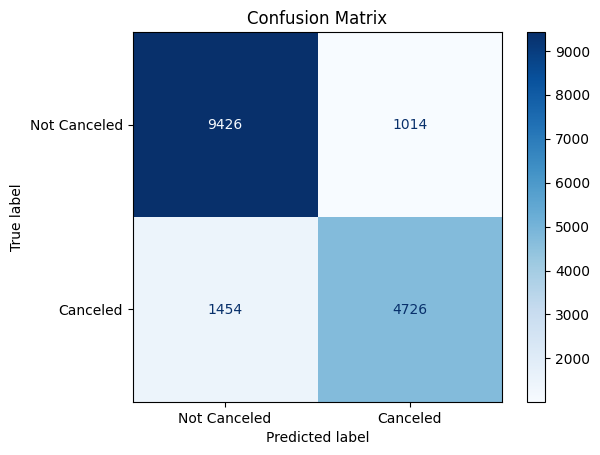

In [ ]:
#confusion matrix of random forest result
cm = confusion_matrix(y_val, y_pred_val_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

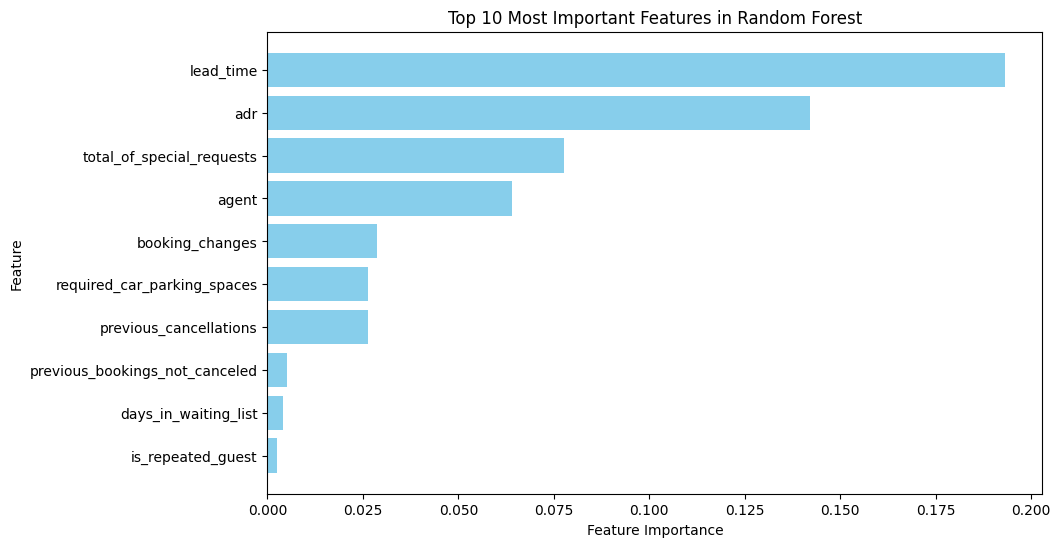

                          Feature  Importance
0                       lead_time    0.193285
7                             adr    0.142087
9       total_of_special_requests    0.077792
5                           agent    0.064159
4                 booking_changes    0.028714
8     required_car_parking_spaces    0.026357
2          previous_cancellations    0.026284
3  previous_bookings_not_canceled    0.005074
6            days_in_waiting_list    0.004083
1               is_repeated_guest    0.002405


In [ ]:
best_rf.fit(X_train_scaled, y_train_smote)
importances = best_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

top_10_features = feature_importance_df.head(10).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features in Random Forest')
plt.gca().invert_yaxis()  # To display the most important features at the top
plt.show()

print(top_10_features)

**Insights:**

- Lead Time: Longer lead times likely correlate with higher cancellation rates, as customers might book far in advance and change plans.
- ADR (Average Daily Rate): Higher ADR bookings may lead to cancellations if customers find cheaper alternatives.
- Total of Special Requests: Guests making special requests might have a clearer intent to stay, lowering their cancellation probability.
- Agent: Different agents may cater to different customer profiles.
- Previous Cancellations: Guests with a history of cancellations are at a higher risk of repeating the behavior.

## Recommendations

1. Hotels can implement flexible pricing options and offer discounts and incentives for earlier bookings with longer lead times. For example, providing non-refundable booking options with lower ADRs for higher lead-time reservations.

2. Given that most of the customers who canceled were from Portugal and other European countries, Hotels could conduct surveys or analyze customer feedback specifically from those guests to understand their cancellation behavior and preferences, and using these insights to refine their offerings.

3. Hotels can try to cater to the customer's special requests and pay attention to those paid a non-refundable deposit. They could introduce a refundable deposit system where customers pay a small amount upfront to reserve their booking. This creates a sense of commitment while giving customers flexibility if plans change.
